In [165]:
using Plots,JLD2,LinearAlgebra

In [166]:
Nx=20
Ny=20
tper=-0.37

tpa=2.0
tNNN=-0.08

α=-1.5
temp=0.09
β=0.15
K=1.0;
KNNN=0.0;
gshear=0.1
trytime_record=1

filling=1.25
#trytime=1

1.25

In [167]:
st=load("test.jld2")
   

Dict{String, Any} with 14 entries:
  "Eelec"          => -2.48005
  "grad"           => [-0.000905828, 0.000103115, -0.000585606, 0.00128441, -0.…
  "spectrum"       => [-4.7612, -4.75955, -4.73848, -4.73758, -4.7371, -4.73445…
  "max_record"     => 0.381789
  "average_record" => 0.201366
  "record_cal"     => Vector{Any}[[-2.37189, -2.37834, -2.37971, -2.37118, -2.3…
  "orbital_id"     => [1 25 … 529 553; 2 26 … 530 554; … ; 23 47 … 551 575; 24 …
  "phonon_id"      => [1 25 … 529 553; 2 26 … 530 554; … ; 23 47 … 551 575; 24 …
  "phonon_coor"    => [-0.216112, 0.0611853, 0.0688993, -0.232035, 0.194135, -0…
  "FL"             => 1.58184
  "ave_npa"        => 720.0
  "E_total"        => -2.3911
  "Egap"           => 0.674958
  "free_energy"    => -2.39111

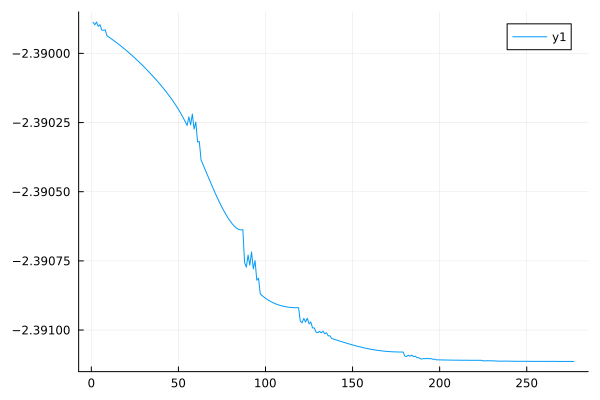

In [168]:
plot(st["record_cal"][1][100:end])

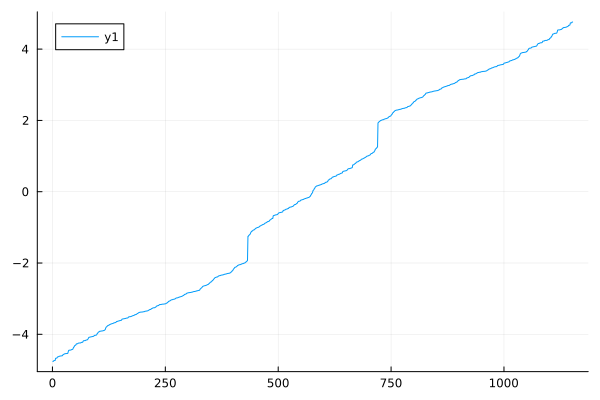

In [169]:
plot(sort(st["spectrum"]))

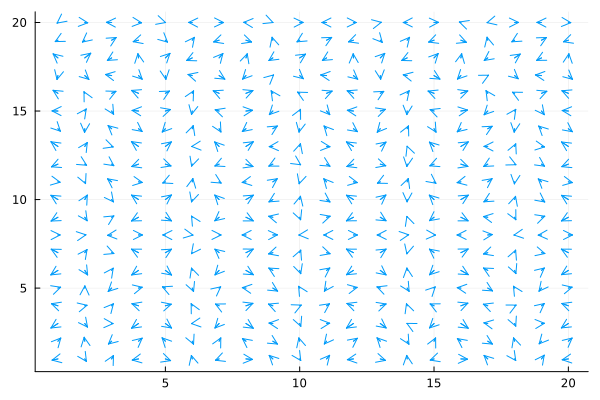

In [170]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [171]:
#savefig(p1,"quiverplot.png")

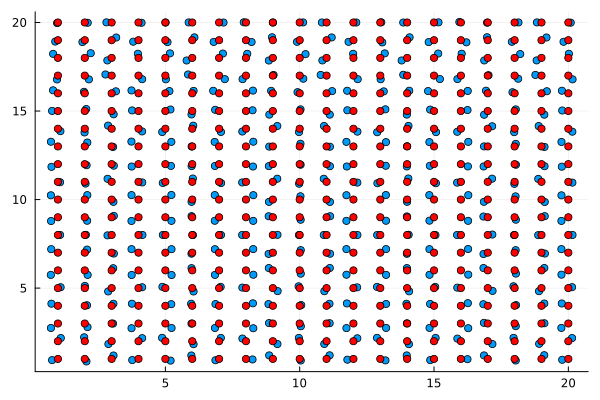

In [172]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [173]:
#savefig(p2,"atomplot.png")

In [174]:
sort(vec(dis_y)-vec(atom_y))

400-element Vector{Float64}:
 -0.26769631992667886
 -0.26643714129549867
 -0.2656487318372136
 -0.26206706852078376
 -0.25911275844049664
 -0.2586129749173205
 -0.2550131116626515
 -0.25420812974837137
 -0.2542019638825046
 -0.25390498675761375
  ⋮
  0.25535260080739164
  0.25785107405877383
  0.25795571283889984
  0.25812396202404564
  0.2586300967883588
  0.26456513991453434
  0.2649292972591546
  0.26621375375930967
  0.2725630788618574

In [175]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

400-element Vector{Float64}:
  1.2176885241769162
  2.2327258154909915
  2.4432803877138913
  2.8446596159275894
  2.973776744014963
  3.2926854360186097
  3.4186350307723297
  3.4984967641050315
  3.8821835487148793
  4.187776089903201
  ⋮
 26.03614684876667
 26.226595224445703
 26.2327859164431
 27.004860578041267
 27.07750420770099
 27.10912429918151
 27.394786108348157
 27.473232986580424
 28.33961983596252

In [176]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

15.956591970334168

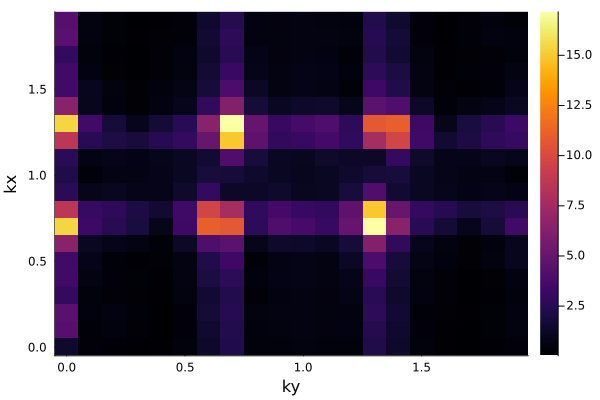

In [177]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [178]:
sort(vec(abs.(Fourier_mode_x)))

400-element Vector{Float64}:
  0.024182703811753588
  0.02418270381175508
  0.041943603181624566
  0.041943603181645576
  0.043136990142558965
  0.043136990142560276
  0.04676398338984274
  0.046763983389844034
  0.05342113568914775
  0.05342113568915735
  ⋮
 10.73953060231008
 11.007188611252925
 11.00718861125293
 14.920810280630542
 14.920810280630548
 15.412481487486076
 15.41248148748609
 17.168799798545038
 17.16879979854506

In [179]:
findmax(abs.(Fourier_mode_x))

(17.16879979854506, CartesianIndex(14, 8))

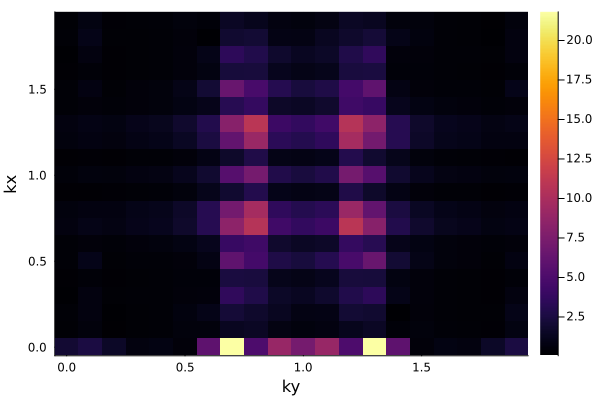

In [180]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [181]:
findmax(abs.(Fourier_mode_y))

(21.81484946267034, CartesianIndex(1, 14))

In [182]:
Fourier_mode_y[8,14]

8.041166343440239 + 0.9778235120646428im

In [183]:
Fourier_mode_x[8,14]

-11.010148365074953 - 13.17362211016991im

In [184]:
Fourier_mode_y[14,8]

8.04116634344022 - 0.977823512064582im

In [185]:
Fourier_mode_x[14,8]

-11.010148365075038 + 13.173622110169868im

In [186]:
Fourier_mode_y[8,8]

8.200299426949032 + 1.7674606959996562im

In [187]:
Fourier_mode_x[8,8]

10.386166180307347 - 2.7322279613887637im